In [ ]:
import pandas as pd
import numpy as np

In [ ]:
class LinearRegression:
    def __init__(self,optimizer = "RMSprop"):
        self.error = None
        self._y = None
        self.b = None
        self.w = None
        self.y = None
        self.x = None
        self.w_error = None
        self.b_error = None
        self.m_w = None
        self.m_b = None
        self.v_w = None
        self.v_b = None
        self.r_v_w = None
        self.r_v_b = None
        self.hat_m_w = None
        self.hat_m_b = None
        self.epoch_count = 1
        self.epoch_limit = None
        self.hat_v_w = None
        self.hat_v_b = None
        self.update_step = lambda: None
        self.metrics = self.Metrics(self)
        self.optimiser = optimizer
    def fit(self,xs,ys,epochs = 100):
        self.x = xs.copy()
        self.y = ys.copy()
        self.w = np.zeros(self.x.shape[1])
        self.b = 0.0
        self.v_w = np.zeros(self.x.shape[1])
        self.m_w = np.zeros(self.x.shape[1])
        self.m_b = 0
        self.v_b = 0
        self._y = np.dot(self.x , self.w) + self.b
        self.error = np.mean((self._y - self.y)**2)
        self.b_error = 2*np.mean(self._y - self.y)
        self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
        self.epoch_limit = epochs
        if self.optimiser == "adam":
            update_step = self.adam
        elif self.optimiser == "RMSprop":
            update_step = self.RMSprop
        elif self.optimiser == "momentum":
            update_step = self.momentum
        elif self.optimiser == "gd":
            update_step = self.gd
        else:
            raise ValueError(f"Unknown optimizer: {self.optimiser}")
        while self.epoch_count <= self.epoch_limit:
            update_step()
            self._y = np.dot(self.x , self.w) + self.b
            self.error = np.mean((self._y - self.y)**2)
            self.b_error = 2*np.mean(self._y - self.y)
            self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
            self.epoch_count += 1
            print(f"Epochs {self.epoch_count -1} / {self.epoch_limit} | loss : {self.error}")
        self.metrics = self.Metrics(self)
    def adam(self, beta1 = 0.9 , beta2 = 0.999 ,epsilon = 10**-8,gamma = 0.001):
        #momentum variables
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        #RMSpropFactors
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        #bias correcting the variance values
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        #RMSpropFactvectors for updating the final values
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        #bias correcting the momentum values
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        #Updating the final value
        self.b = self.b - self.hat_m_b*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.hat_m_w,self.r_v_w)*gamma
    def RMSprop(self,beta2 = 0.999,epsilon = 10**-8, gamma = 0.001):
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        self.r_v_w = 1 / (np.sqrt(self.v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.v_b + epsilon))
        self.b = self.b - self.b_error*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.w_error,self.r_v_w)*gamma
    def momentum(self,beta1 = 0.9 , gamma = 0.001):
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        self.b = self.b - self.m_b*gamma
        self.w = self.w - self.m_w*gamma
    def gd(self,gamma = 0.001):
        self.w = self.w - gamma*self.w_error
        self.b = self.b - self.b_error*gamma
    def predict(self,x):
        out = np.dot(x , self.w) + self.b
        return out
    class Metrics:
        def __init__(self,outer):
            self.parameters = None
            self.outer = outer
            self.w = self.outer.w
            self.b = self.outer.b
        def params(self):
            self.parameters = np.append(self.w , [self.b], axis = None)
            return self.parameters
        def r2_score(self, x, y):
            y_pred = self.outer.predict(x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            return 1 - (ss_res / ss_tot)
        def corr(self,x,y):
            y_pred = self.outer.predict(x)
            return np.corrcoef(y_pred,y)

In [ ]:
df = pd.read_csv('Train.csv')

In [ ]:
df.shape

(600000, 16)

In [ ]:
df.describe()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,target
count,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05,6.000000e+05
mean,-1.724250e-17,-6.458241e-17,-4.861297e-18,2.470320e-17,-9.062380e-18,-7.608728e-18,1.781094e-17,9.409954e-17,1.340794e-16,9.728514e-17,1.076472e-17,-4.689582e-18,-1.280564e-15,-1.376084e-17,-8.700596e-17,1.119460e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-4.334865e+00,-4.316964e+00,-4.705886e+00,-4.828481e+00,-4.615400e+00,-4.705886e+00,-4.498521e+00,-2.351292e+00,-3.578444e+00,-1.580954e+00,-4.494638e+00,-4.812039e+00,-1.942838e+00,-4.763876e+00,-2.996488e+00,-1.398331e+00
25%,-6.717076e-01,-6.792457e-01,-6.746502e-01,-6.733576e-01,-6.752918e-01,-6.746502e-01,-6.749410e-01,-8.647621e-01,-8.053513e-01,-8.723469e-01,-6.756396e-01,-6.753607e-01,-8.306231e-01,-6.759102e-01,-9.531587e-01,-8.697431e-01
50%,3.460588e-04,8.630786e-04,-6.485499e-04,6.301305e-04,-3.731811e-04,-6.485499e-04,-4.382391e-04,-1.175348e-01,-1.089244e-02,-1.069226e-01,-1.193442e-03,-2.621583e-04,7.070111e-02,5.165848e-04,6.334477e-02,-1.809768e-01
75%,6.748988e-01,6.797496e-01,6.755485e-01,6.731165e-01,6.750454e-01,6.755485e-01,6.745637e-01,7.969821e-01,7.823722e-01,8.375296e-01,6.722541e-01,6.745364e-01,8.753109e-01,6.754431e-01,1.007979e+00,7.640746e-01
max,5.071987e+00,4.678014e+00,4.679142e+00,4.708335e+00,4.649655e+00,4.679142e+00,4.717088e+00,4.541923e+00,3.820140e+00,2.463788e+00,4.875410e+00,4.708130e+00,2.817658e+00,5.029459e+00,1.379274e+00,3.615247e+00


In [ ]:
metric = pd.DataFrame({'label' : df.columns,
              'mean' : np.mean(df,axis =0),
              'std' : np.std(df,axis = 0)})

In [ ]:
for col in df.columns:
  df = df[df[col].isna() == False]

In [ ]:
for col in df.columns:
  df[col] = (df[col] - np.mean(df[col]))/np.std(df[col])

In [ ]:
model = LinearRegression(optimizer='gd')
model.fit(df.drop('target',axis = 1).to_numpy(),df.target,epochs = 1000)

Epochs 1 / 1000 | loss : 0.9895679978131928
Epochs 2 / 1000 | loss : 0.9792576041352455
Epochs 3 / 1000 | loss : 0.9690673928375027
Epochs 4 / 1000 | loss : 0.9589959545372403
Epochs 5 / 1000 | loss : 0.9490418964010248
Epochs 6 / 1000 | loss : 0.9392038419503127
Epochs 7 / 1000 | loss : 0.9294804308693321
Epochs 8 / 1000 | loss : 0.9198703188152249
Epochs 9 / 1000 | loss : 0.9103721772304142
Epochs 10 / 1000 | loss : 0.9009846931571822
Epochs 11 / 1000 | loss : 0.891706569054421
Epochs 12 / 1000 | loss : 0.8825365226165401
Epochs 13 / 1000 | loss : 0.8734732865944992
Epochs 14 / 1000 | loss : 0.8645156086189467
Epochs 15 / 1000 | loss : 0.8556622510254296
Epochs 16 / 1000 | loss : 0.8469119906816662
Epochs 17 / 1000 | loss : 0.8382636188168415
Epochs 18 / 1000 | loss : 0.8297159408529062
Epochs 19 / 1000 | loss : 0.8212677762378674
Epochs 20 / 1000 | loss : 0.8129179582810272
Epochs 21 / 1000 | loss : 0.8046653339901615
Epochs 22 / 1000 | loss : 0.7965087639106151
Epochs 23 / 1000 | l

In [ ]:
tdf = pd.read_csv('Test.csv')

In [ ]:
tdf.shape

(150000, 15)

In [ ]:
for col in tdf.columns:
  a = metric.loc[metric.label == col]
  tdf[col] = (tdf[col] - np.float128(a.iloc[:,1].to_numpy()))/np.float128(a.iloc[:,2].to_numpy())

In [ ]:
tdf.describe()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.002047,0.000135,0.004570,-0.001621,0.004605,0.004570,0.000723,-0.001342,-0.001747,-0.000946,-0.002145,-0.000251,-0.000347,0.002608,-0.001489
std,0.998948,1.001518,0.998639,1.003160,0.997634,0.998639,0.998477,0.999923,1.000618,0.998055,0.997309,0.998484,0.998934,0.999245,1.000159
min,-4.563781,-4.398890,-4.218098,-4.682053,-4.238390,-4.218098,-4.555428,-2.108576,-3.781404,-1.580954,-4.247787,-4.411299,-1.930749,-4.393907,-2.996488
25%,-0.673007,-0.684329,-0.664072,-0.681565,-0.664291,-0.664072,-0.670249,-0.871219,-0.807154,-0.872347,-0.676838,-0.675561,-0.819877,-0.671534,-0.953159
50%,-0.000604,0.001540,0.003443,-0.002923,0.002627,0.003443,0.000510,-0.117535,-0.012322,-0.092986,-0.002392,0.000538,0.077417,0.004767,0.063345
75%,0.677523,0.680743,0.677345,0.678421,0.675645,0.677345,0.674065,0.796982,0.779793,0.837530,0.669758,0.676636,0.875311,0.676943,1.007979
max,4.376142,4.480271,4.423872,4.041854,4.432449,4.423872,4.921156,4.503183,3.258345,2.463788,4.414661,4.129017,2.788106,4.438649,1.380354


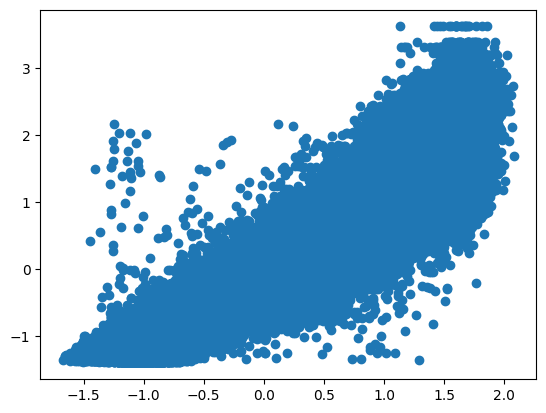

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(model.predict(df.drop('target',axis = 1).to_numpy()),df.target)

In [ ]:
model.predict(tdf.to_numpy())

array([ 1.4783002 , -0.24951504, -0.68442101, ..., -1.05520876,
       -0.76972426,  1.47304118], dtype=float128)

In [ ]:
pred = model.predict(tdf.to_numpy())*np.float128(metric.loc[metric.label == 'target'].iloc[:,2]) + np.float128(metric.loc[metric.label == 'target'].iloc[:,1])

In [ ]:
preddf = pd.DataFrame({'target' : pred})
preddf.to_csv('val_linear.csv')